In [ ]:
########## 1
# Imports: core libraries needed for this notebook
#
# Purpose:
# This notebook performs exploratory data analysis on an IMDb-derived
# analytical dataset stored in a local SQLite database.
#
# Design choice:
# Only standard, commonly available libraries are used:
# sqlite3 for database access, pandas for tabular analysis,
# numpy for numeric transforms, matplotlib for plotting.
##########

# SQLite database connectivity and SQL execution
import sqlite3

# DataFrame operations: filtering, grouping, summarizing, and tabular inspection
import pandas as pd

# Numeric utilities: logarithmic transforms, handling numeric arrays
import numpy as np

# Plotting library for EDA visuals (histograms, scatter plots, box plots)
import matplotlib.pyplot as plt

In [ ]:
########## 2
# Database connection
#
# Purpose:
# Connect to the local SQLite database that contains the IMDb dataset.
# The database is stored locally to ensure reproducibility and eliminate
# external dependencies during analysis.
#
# Output:
# - Active SQLite connection object (conn)
# - Confirmation of SQLite engine version
##########

# Relative path to the SQLite database file inside the repository
db_path = "../imdb_data.db"

# Create connection to SQLite database
conn = sqlite3.connect(db_path)

# Confirm successful connection by retrieving SQLite engine version
cursor = conn.cursor()
cursor.execute("SELECT sqlite_version();")
sqlite_version = cursor.fetchone()[0]
cursor.close()

print("Connected to SQLite version:", sqlite_version)

Connected to SQLite version: 3.40.1


In [ ]:
########## 3
# Load analytical dataset
#
# Purpose:
# Pull the pre-defined SQL view "analysis_movies" into a pandas DataFrame.
#
# Why a SQL view:
# The view standardizes scope and filters in one place, so analysis steps
# remain consistent across reruns and future revisions.
#
# Expected columns (based on the view):
# - tconst, primaryTitle, startYear, runtimeMinutes, genres
# - averageRating, numVotes
##########

query = """
SELECT *
FROM analysis_movies;
"""

# Execute query and load results into a DataFrame
df = pd.read_sql_query(query, conn)

# Confirm dimensions for reproducibility and sanity checking
print("Dataset shape (rows, columns):", df.shape)

# Preview rows to confirm the dataset loaded correctly
df.head(10)

Dataset shape (rows, columns): (331394, 7)


,tconst,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000009,Miss Jerry,1894.0,45,Romance,5.2,231
1,tt0000147,The Corbett-Fitzsimmons Fight,1897.0,100,"Documentary,News,Sport",5.3,578
2,tt0000335,Soldiers of the Cross,1900.0,40,"Biography,Drama",5.5,64
3,tt0000502,Bohemios,1905.0,100,None,3.1,25
4,tt0000574,The Story of the Kelly Gang,1906.0,70,"Action,Adventure,Biography",6.0,1039
5,tt0000591,The Prodigal Son,1907.0,90,Drama,4.8,36
6,tt0000615,Robbery Under Arms,1907.0,None,Drama,3.6,32
7,tt0000630,Hamlet,1908.0,None,Drama,3.0,36
8,tt0000675,Don Quijote,1908.0,None,Drama,4.0,26
9,tt0000679,The Fairylogue and Radio-Plays,1908.0,120,"Adventure,Fantasy",5.1,81


In [6]:
########## 4
# Structural inspection
#
# Purpose:
# Confirm column types, missingness patterns, and numerical ranges.
# This is the first checkpoint before any grouping or modeling.
#
# Outputs:
# - df.info(): column names, data types, non-null counts
# - df.describe(): numeric summary statistics for numeric columns
##########

df.info()

# Descriptive statistics for numeric columns
# Note: pandas describes only numeric columns by default
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331394 entries, 0 to 331393
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tconst          331394 non-null  object 
 1   primaryTitle    331393 non-null  object 
 2   startYear       331361 non-null  float64
 3   runtimeMinutes  298981 non-null  object 
 4   genres          320557 non-null  object 
 5   averageRating   331394 non-null  float64
 6   numVotes        331394 non-null  int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 17.7+ MB


,startYear,averageRating,numVotes
count,331361.000000,331394.000000,3.313940e+05
mean,1997.402872,6.186075,3.737174e+03
std,26.199632,1.384322,3.770491e+04
min,1894.000000,1.000000,5.000000e+00
25%,1982.000000,5.400000,2.000000e+01
50%,2008.000000,6.300000,6.500000e+01
75%,2017.000000,7.100000,3.340000e+02
max,2025.000000,10.000000,3.128623e+06


In [7]:
########## 5
# Missing value assessment
#
# Purpose:
# Identify missing values by column.
# Missingness affects grouping (genre comparisons), transformations,
# and downstream modeling choices.
##########

missing_counts = df.isna().sum().sort_values(ascending=False)

print("Missing values by column (descending):")
print(missing_counts)

Missing values by column (descending):
runtimeMinutes    32413
genres            10837
startYear            33
primaryTitle          1
tconst                0
averageRating         0
numVotes              0
dtype: int64


In [8]:
########## 6
# Feature preparation: engagement variable
#
# Purpose:
# Define an engagement measure for analysis and visualization.
#
# Design choice:
# "numVotes" is used as the primary engagement proxy because it reflects
# participation volume. Vote counts are typically heavily right-skewed,
# so a log transform is created to support comparisons and modeling.
#
# Implementation:
# log_votes = log( numVotes + 1 )
# log1p() is used to handle numVotes = 0 safely.
##########

# Ensure vote counts are numeric
# This protects against unexpected types if data was imported as text
df["numVotes"] = pd.to_numeric(df["numVotes"], errors="coerce")

# Log-transform vote counts for stability and interpretability
df["log_votes"] = np.log1p(df["numVotes"])

# Quick verification of the new field
df[["numVotes", "log_votes"]].head(10)

,numVotes,log_votes
0,231,5.446737
1,578,6.361302
2,64,4.174387
3,25,3.258097
4,1039,6.946976
5,36,3.610918
6,32,3.496508
7,36,3.610918
8,26,3.295837
9,81,4.406719


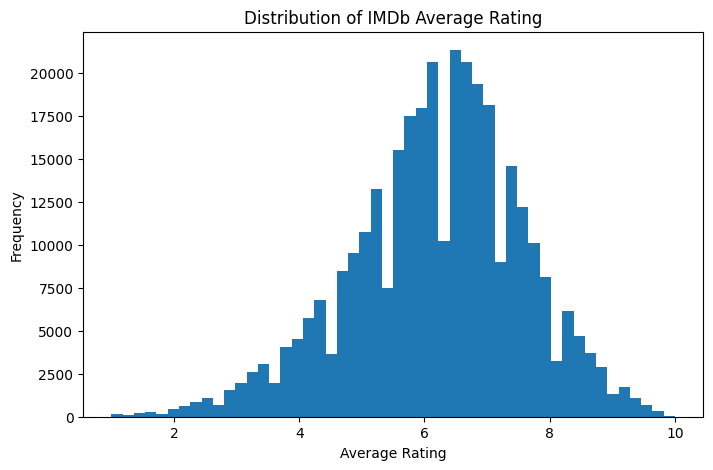

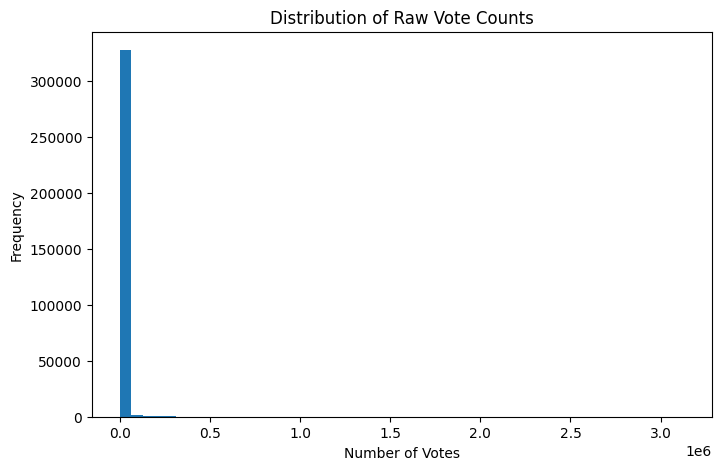

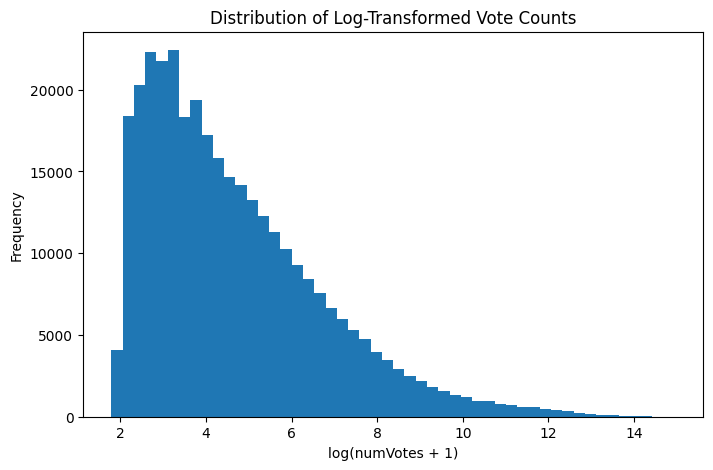

In [9]:
########## 7
# Distribution checks: rating and engagement
#
# Purpose:
# Visualize key variable distributions to understand:
# - range and central tendency
# - skew and outliers
# - whether transforms are needed for meaningful comparisons
#
# Plots produced:
# - Histogram of averageRating
# - Histogram of raw numVotes
# - Histogram of log_votes
##########

# Histogram: averageRating
plt.figure(figsize=(8, 5))
plt.hist(df["averageRating"].dropna(), bins=50)
plt.title("Distribution of IMDb Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.show()

# Histogram: raw numVotes
plt.figure(figsize=(8, 5))
plt.hist(df["numVotes"].dropna(), bins=50)
plt.title("Distribution of Raw Vote Counts")
plt.xlabel("Number of Votes")
plt.ylabel("Frequency")
plt.show()

# Histogram: log-transformed vote counts
plt.figure(figsize=(8, 5))
plt.hist(df["log_votes"].dropna(), bins=50)
plt.title("Distribution of Log-Transformed Vote Counts")
plt.xlabel("log(numVotes + 1)")
plt.ylabel("Frequency")
plt.show()

In [10]:
########## 8
# Remove rows with missing genre information
#
# Rationale:
# Genre is a primary production attribute in this analysis.
# Rows without genre cannot be categorized meaningfully.
##########

df = df[df["genres"].notna()].copy()

print("Shape after removing missing genres:", df.shape)

Shape after removing missing genres: (320557, 8)


In [11]:
########## 9
# Inspect genre ordering structure
#
# Purpose:
# Determine whether genres appear alphabetically within each record.
# This verifies whether the first genre represents a primary category
# or simply alphabetical ordering.
##########

# Take a sample of rows with multiple genres
sample_multi = df[df["genres"].str.contains(",")].sample(20, random_state=42)

# Split genres into lists
sample_multi["genre_list"] = sample_multi["genres"].str.split(",")

# Check alphabetical ordering
sample_multi["is_alphabetical"] = sample_multi["genre_list"].apply(
    lambda x: x == sorted(x)
)

sample_multi[["genres", "genre_list", "is_alphabetical"]]

,genres,genre_list,is_alphabetical
270571,"Comedy,Sport","[Comedy, Sport]",True
162195,"Drama,Western","[Drama, Western]",True
149932,"Comedy,Drama,Romance","[Comedy, Drama, Romance]",True
308023,"Action,Biography,Drama","[Action, Biography, Drama]",True
204582,"Documentary,History","[Documentary, History]",True
171006,"Action,Drama","[Action, Drama]",True
190352,"Animation,Music","[Animation, Music]",True
129,"Drama,History","[Drama, History]",True
274080,"Drama,Horror,Mystery","[Drama, Horror, Mystery]",True
288874,"Action,Crime,Mystery","[Action, Crime, Mystery]",True


In [33]:
########## 10
# One-hot encode multi-label genres
#
# Purpose:
# Convert comma-separated genre strings into binary indicator columns.
# Each genre becomes a 0/1 feature for modeling.
#
# Notes:
# - Assumes missing genres have already been removed.
# - Safe to rerun without duplicating columns.
##########

# Remove existing genre_ columns if cell is rerun
df = df.loc[:, ~df.columns.str.startswith("genre_")]

# Split genres into lists
df["genre_list"] = df["genres"].str.split(",")

# Explode for encoding
genre_exploded = df.explode("genre_list")

# One-hot encode and ensure integer type
genre_dummies = pd.get_dummies(
    genre_exploded["genre_list"],
    prefix="genre",
    dtype=int
)

# Recombine to original index
genre_matrix = genre_dummies.groupby(genre_exploded.index).max()

# Merge back into main dataframe
df = df.join(genre_matrix)

print("New shape after genre encoding:", df.shape)

New shape after genre encoding: (318870, 31)


In [34]:
########## 11
# Rename helper column to avoid accidental inclusion in regression
#
# Purpose:
# The column "genre_list" contains Python lists used for encoding.
# Because it begins with "genre_", it can accidentally be included
# in regression predictor selection logic.
# Renaming prevents that issue permanently.
##########

df = df.rename(columns={"genre_list": "genres_list"})

print("Columns renamed successfully.")

Columns renamed successfully.


In [35]:
########## 11a
# Genre frequency distribution
#
# Purpose:
# Determine how often each genre appears after cleaning.
# This helps identify rare categories that may destabilize regression.
##########

genre_counts = (
    df["genres"]
    .str.split(",")
    .explode()
    .value_counts()
    .sort_values(ascending=False)
)

genre_counts.head(20)

genres
Drama          151007
Comedy          79941
Documentary     53975
Romance         36307
Action          34331
Thriller        28361
Crime           28175
Horror          25754
Adventure       20266
Mystery         13194
Family          12830
Biography       10555
Fantasy         10111
History          9292
Music            8507
Sci-Fi           7903
Musical          6975
War              6687
Animation        6037
Western          5034
Name: count, dtype: int64

In [36]:
########## 11b
# Genre frequency distribution
#
# Purpose:
# Determine how often each genre appears after cleaning.
# This helps identify rare categories that may destabilize regression.
##########

genre_counts = (
    df["genres"]
    .str.split(",")
    .explode()
    .value_counts()
    .sort_values(ascending=False)
)

genre_counts.tail(10)

genres
Biography    10555
Fantasy      10111
History       9292
Music         8507
Sci-Fi        7903
Musical       6975
War           6687
Animation     6037
Western       5034
Sport         4245
Name: count, dtype: int64

In [37]:
########## 12
# Count total unique genres
##########

print("Total unique genres:", genre_counts.shape[0])

##########
# Identify very low-frequency genres
##########

rare_genres = genre_counts[genre_counts < 1000]
rare_genres

Total unique genres: 21


Series([], Name: count, dtype: int64)

In [39]:
########## 13
# Remove extremely low-frequency genres (structural cutoff)
#
# Rationale:
# Genres below the natural frequency break (~4000 observations)
# are excluded to ensure stable estimation.
##########

# Define minimum threshold
min_threshold = 4000

valid_genres = genre_counts[genre_counts >= min_threshold].index.tolist()

def genre_filter(genre_string):
    return all(g in valid_genres for g in genre_string.split(","))

df = df[df["genres"].apply(genre_filter)].copy()

print("Shape after removing rare genres:", df.shape)

Shape after removing rare genres: (318870, 31)


In [40]:
########## 14
# Count number of genres per movie
#
# Purpose:
# Determine how many genres each movie is assigned.
# This informs whether treating genres as multi-label is appropriate,
# and whether most films cluster around 1–2 genres.
##########

# Count number of genres per movie
df["genre_count"] = df["genres"].str.split(",").apply(len)

# Frequency distribution
genre_count_distribution = df["genre_count"].value_counts().sort_index()

print("Distribution of number of genres per movie:")
print(genre_count_distribution)

# Also show proportions
print("\nProportion of dataset:")
print((genre_count_distribution / len(df)).round(4))

Distribution of number of genres per movie:
genre_count
1    154719
2     87685
3     76466
Name: count, dtype: int64

Proportion of dataset:
genre_count
1    0.4852
2    0.2750
3    0.2398
Name: count, dtype: float64


In [42]:
########## 15
# Define dependent variable: log-transformed vote count
#
# Purpose:
# Engagement volume (numVotes) is highly right-skewed.
# A log transformation stabilizes variance and improves
# suitability for linear modeling.
##########

import numpy as np

df["log_votes"] = np.log(df["numVotes"] + 1)

print(df[["numVotes", "log_votes"]].head())

   numVotes  log_votes
0       231   5.446737
2        64   4.174387
4      1039   6.946976
5        36   3.610918
6        32   3.496508


In [43]:
########## 16
# Build X using only valid numeric genre dummy columns
##########

# Start with all columns that look like genre dummies
genre_cols = [c for c in df.columns if c.startswith("genre_")]

# Drop Drama for the reference category
genre_cols = [c for c in genre_cols if c != "genre_Drama"]

# Keep only numeric/bool columns (true dummy indicators)
valid_genre_cols = [c for c in genre_cols if pd.api.types.is_bool_dtype(df[c]) or pd.api.types.is_numeric_dtype(df[c])]

# Confirm we are not accidentally keeping list-like columns
excluded = sorted(set(genre_cols) - set(valid_genre_cols))
print("Valid genre predictors:", len(valid_genre_cols))
print("Excluded genre_ columns (not numeric/bool):", excluded)

X = df[valid_genre_cols].astype(int)
y = df["log_votes"].astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

Valid genre predictors: 21
Excluded genre_ columns (not numeric/bool): []
X shape: (318870, 21)
y shape: (318870,)


In [ ]:
########## 17a
# Fit OLS regression: log_votes ~ genre indicators
########## 17
import statsmodels.api as sm

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_votes   R-squared:                       0.169
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     3096.
Date:                Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                        22:14:06   Log-Likelihood:            -6.5452e+05
No. Observations:              318870   AIC:                         1.309e+06
Df Residuals:                  318848   BIC:                         1.309e+06
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 3.3088      0.01

In [ ]:
########## 17b (Model WITHOUT genre_count)
# Fit OLS regression using only genre indicator variables
# Explicitly exclude both Drama and genre_count
##########

import statsmodels.api as sm

# Collect all genre dummy columns
genre_cols = [c for c in df.columns if c.startswith("genre_")]

# Explicitly exclude baseline and genre_count
genre_cols = [
    c for c in genre_cols
    if c not in ["genre_Drama", "genre_count"]
]

print("Predictors being used:", len(genre_cols))

X = df[genre_cols].astype(int)
y = df["log_votes"]

X = sm.add_constant(X)

model_no_count = sm.OLS(y, X).fit()

print(model_no_count.summary())

Predictors being used: 20
                            OLS Regression Results                            
Dep. Variable:              log_votes   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                     2693.
Date:                Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                        22:22:59   Log-Likelihood:            -6.5922e+05
No. Observations:              318870   AIC:                         1.318e+06
Df Residuals:                  318849   BIC:                         1.319e+06
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const       

#### Model Specification Note: Treatment of genre_count

Two regression specifications are estimated above (see code cells 17a and 17b) to evaluate the structural role of genre classification. The first model includes a variable representing the number of genres assigned to each film (genre_count). This variable captures whether films labeled with multiple genres exhibit systematically different engagement patterns.

Because genre_count is derived from the same genre indicator variables used in the model, its inclusion alters the interpretation of individual genre coefficients. When genre_count is included, coefficients represent the marginal association of a specific genre holding constant the total number of genre labels assigned. When genre_count is excluded, coefficients reflect the overall association between the presence of that genre and engagement, including any structural effect related to multi-genre classification.

Both specifications are presented for transparency and comparative interpretation.

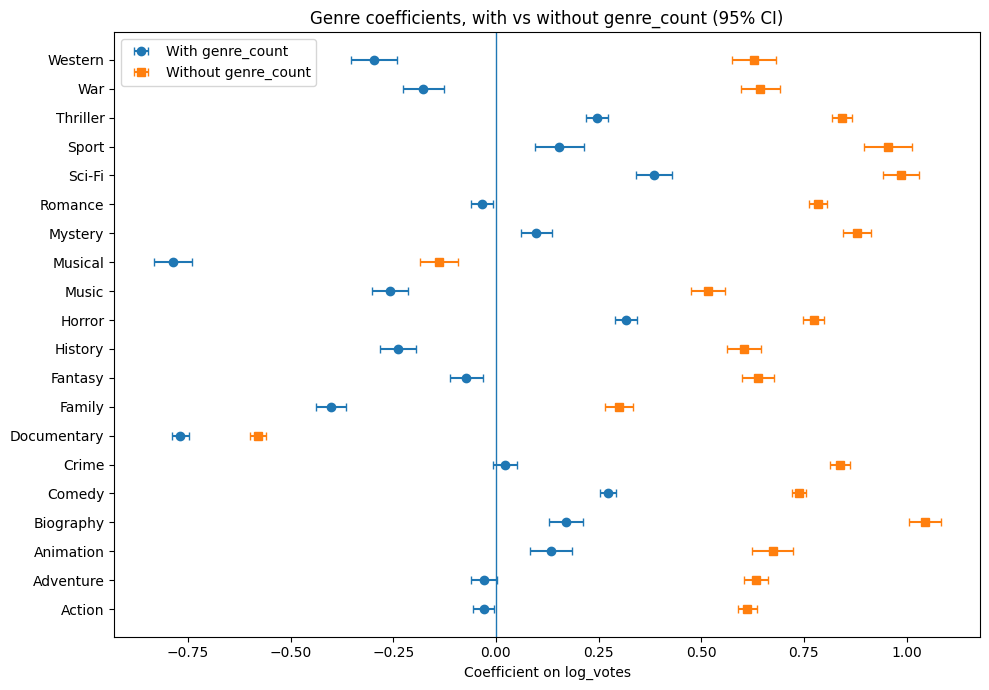

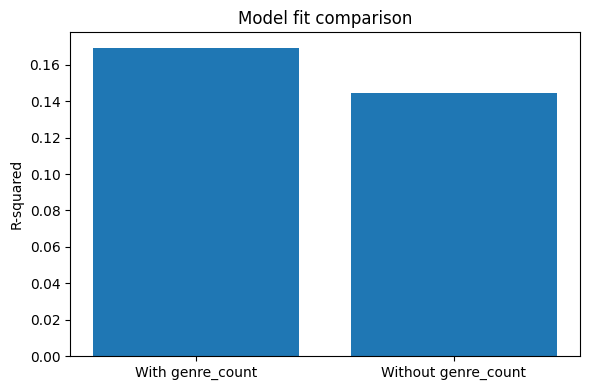

In [49]:
########## 17c
# Visual comparison: coefficients with and without `genre_count`
#
# Purpose:
# Show how including `genre_count` changes estimated genre associations with engagement.
#
# Inputs:
# - model          : OLS fit that includes genre_count (your 17a result)
# - model_no_count : OLS fit that excludes genre_count (your 17b result)
#
# Output:
# - Coefficient comparison figure with 95% confidence intervals
# - R-squared comparison figure
##########

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##########
# Extract and align coefficients for the same set of genre predictors
##########

# Keep only genre_* terms, exclude const and genre_count where present
params_a = model.params.copy()
ci_a = model.conf_int().copy()
params_b = model_no_count.params.copy()
ci_b = model_no_count.conf_int().copy()

def keep_genres(params, ci):
    keep = [i for i in params.index if i.startswith("genre_") and i != "genre_count"]
    return params.loc[keep], ci.loc[keep]

params_a, ci_a = keep_genres(params_a, ci_a)
params_b, ci_b = keep_genres(params_b, ci_b)

# Align to common index, both models should have the same genre set here
common = sorted(set(params_a.index).intersection(set(params_b.index)))
params_a, ci_a = params_a.loc[common], ci_a.loc[common]
params_b, ci_b = params_b.loc[common], ci_b.loc[common]

genres = [g.replace("genre_", "") for g in common]

##########
# Plot 1: coefficient comparison with 95% CI
##########

ypos = np.arange(len(genres))

a_err_low = params_a.values - ci_a[0].values
a_err_high = ci_a[1].values - params_a.values

b_err_low = params_b.values - ci_b[0].values
b_err_high = ci_b[1].values - params_b.values

plt.figure(figsize=(10, max(6, 0.35 * len(genres))))
plt.axvline(0, linewidth=1)

# Model A: with genre_count
plt.errorbar(
    params_a.values, ypos,
    xerr=[a_err_low, a_err_high],
    fmt="o", capsize=3, label="With genre_count"
)

# Model B: without genre_count
plt.errorbar(
    params_b.values, ypos,
    xerr=[b_err_low, b_err_high],
    fmt="s", capsize=3, label="Without genre_count"
)

plt.yticks(ypos, genres)
plt.xlabel("Coefficient on log_votes")
plt.title("Genre coefficients, with vs without genre_count (95% CI)")
plt.legend()
plt.tight_layout()
plt.show()

##########
# Plot 2: R-squared comparison
##########

plt.figure(figsize=(6, 4))
plt.bar(["With genre_count", "Without genre_count"], [model.rsquared, model_no_count.rsquared])
plt.ylabel("R-squared")
plt.title("Model fit comparison")
plt.tight_layout()
plt.show()

In [45]:
########## 18
# Fix statsmodels dtype issue for regression
#
# Purpose:
# Statsmodels OLS requires numeric arrays.
# If any predictors are dtype "object", OLS will fail.
#
# Output:
# - List of non-numeric columns (should be empty after fix)
# - Confirmed dtypes for X and y
##########

# Confirm y is numeric
print("y dtype:", y.dtype)

# Identify any non-numeric columns in X
non_numeric_cols = X.columns[X.dtypes == "object"].tolist()
print("Non-numeric columns in X:", non_numeric_cols)

# Force all predictors to numeric (safe for 0/1 dummy columns)
X = X.apply(pd.to_numeric, errors="coerce")

# Check for any new missing values introduced by coercion
missing_after_coerce = X.isna().sum().sort_values(ascending=False)
print("\nMissing values introduced by coercion (top 10):")
print(missing_after_coerce.head(10))

# If coercion introduced NaNs, something is wrong with those columns
# Drop rows with NaNs in X or y before fitting
model_df = pd.concat([y, X], axis=1).dropna()
y_clean = model_df["log_votes"]
X_clean = model_df.drop(columns=["log_votes"])

print("\nClean shapes:")
print("X_clean:", X_clean.shape)
print("y_clean:", y_clean.shape)

y dtype: float64
Non-numeric columns in X: []

Missing values introduced by coercion (top 10):
const                0
genre_Action         0
genre_Adventure      0
genre_Animation      0
genre_Biography      0
genre_Comedy         0
genre_Crime          0
genre_Documentary    0
genre_Family         0
genre_Fantasy        0
dtype: int64

Clean shapes:
X_clean: (318870, 22)
y_clean: (318870,)
